**ПРОЕКТ**

**ЦЕЛЬ:**\
Разработать модель машинного обучения, предсказывающая высокий риск поражения сердца, а также подготовить библиотеку и интерфейс к ней для предсказания на тестовой выборке.

**ЗАДАЧИ:**\
● Предобработка данных. Отбор данных, выявление утечки данных\
● Исследовательский анализ данных\
● Обучение модели\
● Подготовка предсказания на тестовой выборке. Файл предсказаний должен быть в csv формате и содержать 2 столбца: “id” и “prediction”\
● Подготовка скриптов и библиотеки для обработки данных и предсказания на тестовой выборке\
● Написание инструмента для тестирования\
● Оформление документации

In [78]:
#Установка библиотек
!pip install -U scikit-learn imbalanced-learn
!pip install -q phik

#Импорт библиотек

#Библиотеки для работы с данными и исследовательскому анализу
import pandas as pd
import numpy as np
import phik
from scipy import stats as st

#Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

#Разработка моделей
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

#Метрики
from sklearn.metrics import recall_score

#Константы
RANDOM_STATE = 42

**------------------------------------------------------------**Исследование датасета**------------------------------------------------------------**

In [79]:
#Открытие датасета
data = pd.read_csv('heart_train.csv')

In [80]:
#Просмотр датасета
data

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,...,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,...,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,...,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,...,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,...,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8680,8680,0.359551,0.357143,0.040330,1.0,0.0,1.0,1.0,1.0,0.926662,...,0.0,0.166667,0.0,0.136364,0.006771,0.088261,Male,0.632258,0.511628,5734
8681,8681,0.516854,0.832143,0.036664,1.0,1.0,1.0,1.0,1.0,0.455572,...,6.0,0.833333,0.0,0.195652,0.008339,0.000777,Male,0.561290,0.511628,5191
8682,8682,0.471910,0.067857,0.023831,1.0,0.0,1.0,0.0,1.0,0.076336,...,1.0,0.833333,0.0,0.227018,0.048229,0.036512,Male,0.374194,0.558140,5390
8683,8683,0.595506,0.000000,0.075160,0.0,1.0,1.0,0.0,1.0,0.371759,...,4.0,0.500000,0.0,0.227018,0.048229,0.036512,Male,0.477419,0.744186,860


In [81]:
#Просмотр типов данных и размерности датасета
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

In [82]:
#Просмотр столбцов (признаков)
data.columns

Index(['Unnamed: 0', 'Age', 'Cholesterol', 'Heart rate', 'Diabetes',
       'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption',
       'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems',
       'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income',
       'BMI', 'Triglycerides', 'Physical Activity Days Per Week',
       'Sleep Hours Per Day', 'Heart Attack Risk (Binary)', 'Blood sugar',
       'CK-MB', 'Troponin', 'Gender', 'Systolic blood pressure',
       'Diastolic blood pressure', 'id'],
      dtype='object')

In [83]:
#Определение количественных и категориальных признаков:
for column in data.columns:
    print(column, ':')
    print(len(data[column].unique()))
    print('------------------------------')

Unnamed: 0 :
8685
------------------------------
Age :
77
------------------------------
Cholesterol :
282
------------------------------
Heart rate :
87
------------------------------
Diabetes :
3
------------------------------
Family History :
3
------------------------------
Smoking :
3
------------------------------
Obesity :
3
------------------------------
Alcohol Consumption :
3
------------------------------
Exercise Hours Per Week :
7933
------------------------------
Diet :
4
------------------------------
Previous Heart Problems :
3
------------------------------
Medication Use :
3
------------------------------
Stress Level :
11
------------------------------
Sedentary Hours Per Day :
7933
------------------------------
Income :
7808
------------------------------
BMI :
7933
------------------------------
Triglycerides :
772
------------------------------
Physical Activity Days Per Week :
9
------------------------------
Sleep Hours Per Day :
8
-----------------------------

In [84]:
#Выделяем количественные признаки и категориальные признаки в зависимости от количетва значений:
quantitative = []
category = []
for column in data.columns:
    if len(data[column].unique()) > 20:
        quantitative.append(column)
    else: category.append(column)

In [85]:
#Удаление столбцов 'Unnamed: 0', 'id' :
del quantitative[0]
del quantitative[-1]

In [86]:
#Просмотр количественных признаков:
quantitative

['Age',
 'Cholesterol',
 'Heart rate',
 'Exercise Hours Per Week',
 'Sedentary Hours Per Day',
 'Income',
 'BMI',
 'Triglycerides',
 'Blood sugar',
 'CK-MB',
 'Troponin',
 'Systolic blood pressure',
 'Diastolic blood pressure']

In [87]:
#Просмотр категориальных признаков:
category

['Diabetes',
 'Family History',
 'Smoking',
 'Obesity',
 'Alcohol Consumption',
 'Diet',
 'Previous Heart Problems',
 'Medication Use',
 'Stress Level',
 'Physical Activity Days Per Week',
 'Sleep Hours Per Day',
 'Heart Attack Risk (Binary)',
 'Gender']

In [88]:
#Просмотр уникальных значений категориальных признаков:
for cat in category:
    print(data[cat].value_counts())
    print('-------------------------')

Diabetes
1.0    5505
0.0    2937
Name: count, dtype: int64
-------------------------
Family History
0.0    4309
1.0    4133
Name: count, dtype: int64
-------------------------
Smoking
1.0    7622
0.0     820
Name: count, dtype: int64
-------------------------
Obesity
0.0    4235
1.0    4207
Name: count, dtype: int64
-------------------------
Alcohol Consumption
1.0    5082
0.0    3360
Name: count, dtype: int64
-------------------------
Diet
1    2863
2    2796
0    2783
3     243
Name: count, dtype: int64
-------------------------
Previous Heart Problems
0.0    4260
1.0    4182
Name: count, dtype: int64
-------------------------
Medication Use
1.0    4231
0.0    4211
Name: count, dtype: int64
-------------------------
Stress Level
7.0     869
4.0     857
2.0     854
9.0     852
8.0     844
3.0     841
1.0     840
5.0     833
6.0     828
10.0    824
Name: count, dtype: int64
-------------------------
Physical Activity Days Per Week
3.0    1091
2.0    1087
1.0    1069
7.0    1063
6.0    

In [89]:
#Корректирова категориального признака Gender :
data['Gender'] = data['Gender'].replace('1.0', 'Male')
data['Gender'] = data['Gender'].replace('0.0', 'Female')

In [90]:
#Проверка категориального признака Gender :
print(data['Gender'].value_counts())

Gender
Male      6038
Female    2647
Name: count, dtype: int64


In [91]:
#Изменение типа данных категориальных столбцов :
for cat in category:
    data[cat] = data[cat].astype('str')

In [92]:
#Описательная статистика количественных признаков:
for q in quantitative:
    print(data[q].describe())
    print('--------------------')

count    8685.000000
mean        0.449958
std         0.231174
min         0.000000
25%         0.258427
50%         0.460674
75%         0.640449
max         1.000000
Name: Age, dtype: float64
--------------------
count    8685.000000
mean        0.501070
std         0.284716
min         0.000000
25%         0.267857
50%         0.499780
75%         0.746429
max         1.000000
Name: Cholesterol, dtype: float64
--------------------
count    8685.000000
mean        0.050658
std         0.023453
min         0.000000
25%         0.034830
50%         0.050412
75%         0.065995
max         1.000000
Name: Heart rate, dtype: float64
--------------------
count    8685.000000
mean        0.503378
std         0.284810
min         0.000000
25%         0.263286
50%         0.502110
75%         0.748709
max         1.000000
Name: Exercise Hours Per Week, dtype: float64
--------------------
count    8685.000000
mean        0.499164
std         0.285340
min         0.000000
25%         0.255875


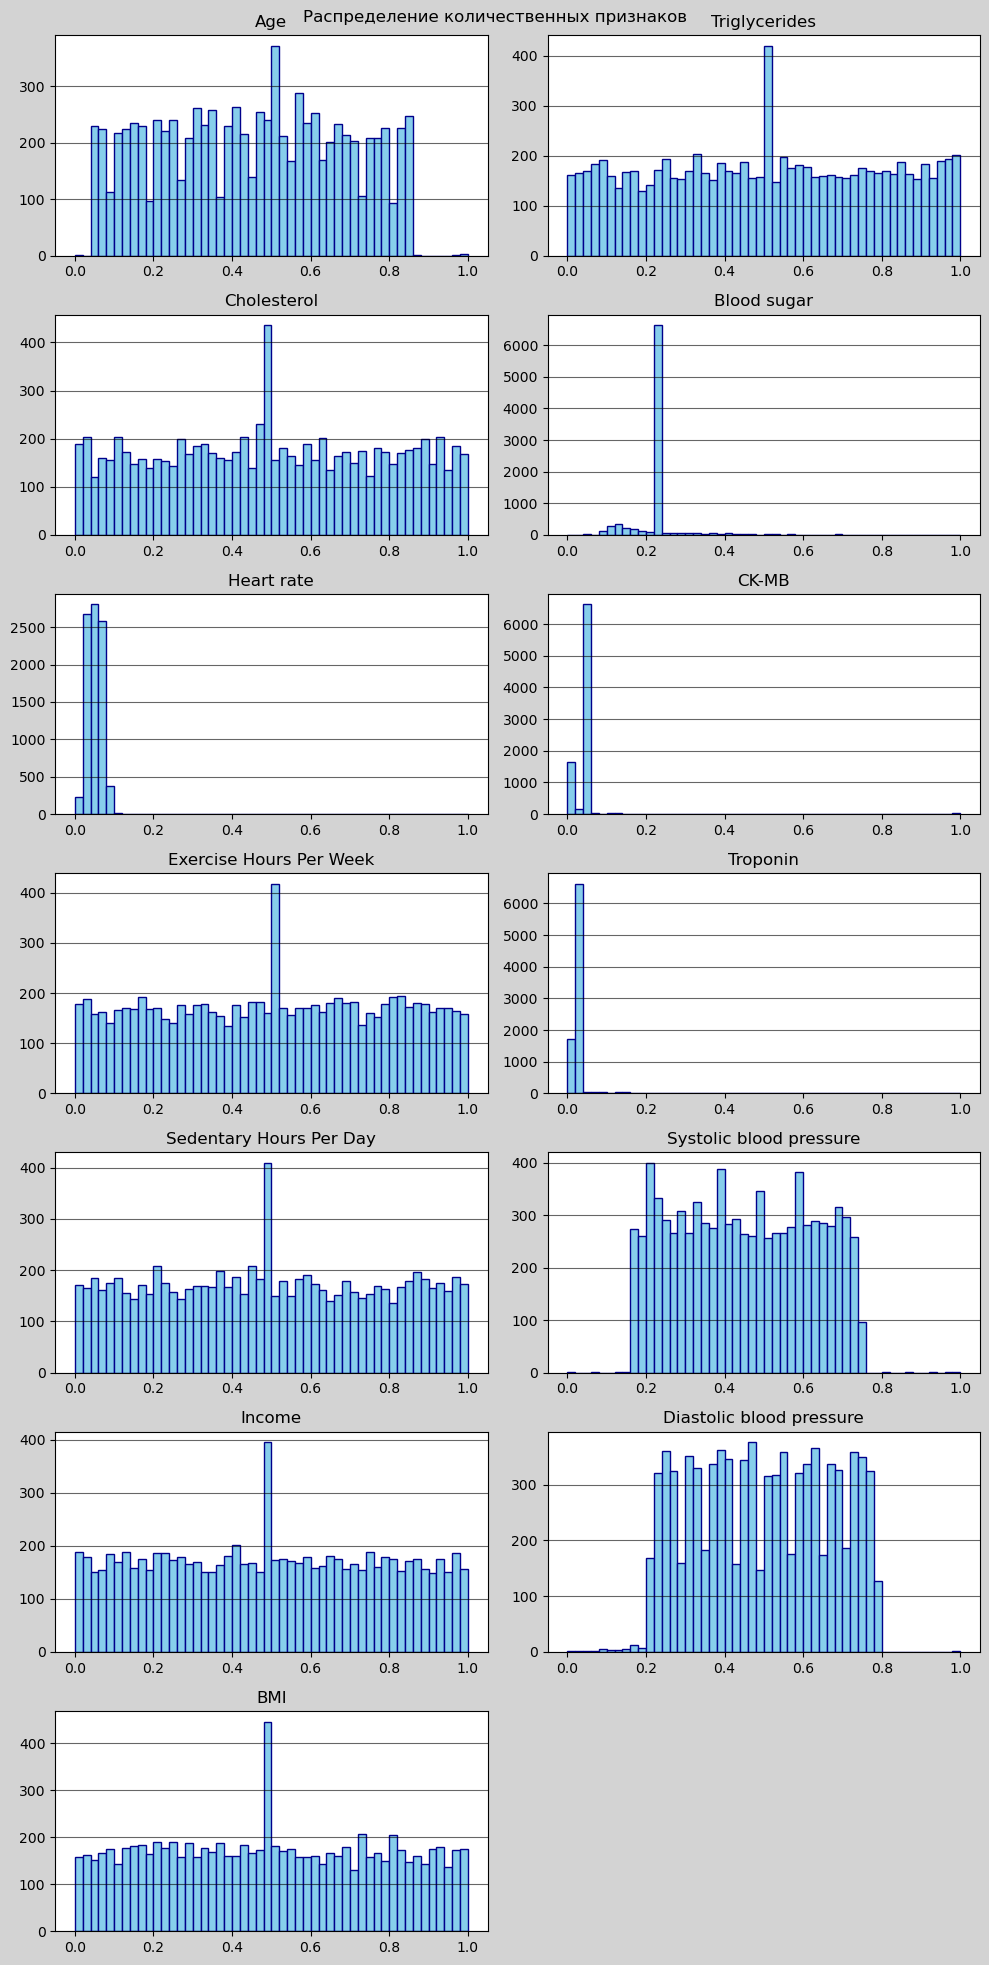

In [93]:
#Визуализация распределений количественных признаков :
fig, axes = plt.subplots(7, 2, figsize=(10, 20), facecolor='lightgray')
bins = 50
color = 'skyblue'
edgecolor = 'darkblue'
axes[0, 0].hist(data[quantitative[0]], bins=bins, color=color, edgecolor=edgecolor)
axes[1, 0].hist(data[quantitative[1]], bins=bins, color=color, edgecolor=edgecolor)
axes[2, 0].hist(data[quantitative[2]], bins=bins, color=color, edgecolor=edgecolor)
axes[3, 0].hist(data[quantitative[3]], bins=bins, color=color, edgecolor=edgecolor)
axes[4, 0].hist(data[quantitative[4]], bins=bins, color=color, edgecolor=edgecolor)
axes[5, 0].hist(data[quantitative[5]], bins=bins, color=color, edgecolor=edgecolor)
axes[6, 0].hist(data[quantitative[6]], bins=bins, color=color, edgecolor=edgecolor)
axes[0, 1].hist(data[quantitative[7]], bins=bins, color=color, edgecolor=edgecolor)
axes[1, 1].hist(data[quantitative[8]], bins=bins, color=color, edgecolor=edgecolor)
axes[2, 1].hist(data[quantitative[9]], bins=bins, color=color, edgecolor=edgecolor)
axes[3, 1].hist(data[quantitative[10]], bins=bins, color=color, edgecolor=edgecolor)
axes[4, 1].hist(data[quantitative[11]], bins=bins, color=color, edgecolor=edgecolor)
axes[5, 1].hist(data[quantitative[12]], bins=bins, color=color, edgecolor=edgecolor)
axes[6, 1].axis('off')
axes[0, 0].set_title(quantitative[0])
axes[1, 0].set_title(quantitative[1])
axes[2, 0].set_title(quantitative[2])
axes[3, 0].set_title(quantitative[3])
axes[4, 0].set_title(quantitative[4])
axes[5, 0].set_title(quantitative[5])
axes[6, 0].set_title(quantitative[6])
axes[0, 1].set_title(quantitative[7])
axes[1, 1].set_title(quantitative[8])
axes[2, 1].set_title(quantitative[9])
axes[3, 1].set_title(quantitative[10])
axes[4, 1].set_title(quantitative[11])
axes[5, 1].set_title(quantitative[12])
axes[0, 0].grid(axis='y', color='black', alpha=0.6)
axes[1, 0].grid(axis='y', color='black', alpha=0.6)
axes[2, 0].grid(axis='y', color='black', alpha=0.6)
axes[3, 0].grid(axis='y', color='black', alpha=0.6)
axes[4, 0].grid(axis='y', color='black', alpha=0.6)
axes[5, 0].grid(axis='y', color='black', alpha=0.6)
axes[6, 0].grid(axis='y', color='black', alpha=0.6)
axes[0, 1].grid(axis='y', color='black', alpha=0.6)
axes[1, 1].grid(axis='y', color='black', alpha=0.6)
axes[2, 1].grid(axis='y', color='black', alpha=0.6)
axes[3, 1].grid(axis='y', color='black', alpha=0.6)
axes[4, 1].grid(axis='y', color='black', alpha=0.6)
axes[5, 1].grid(axis='y', color='black', alpha=0.6)
fig.suptitle('Распределение количественных признаков')
plt.tight_layout()
plt.show()

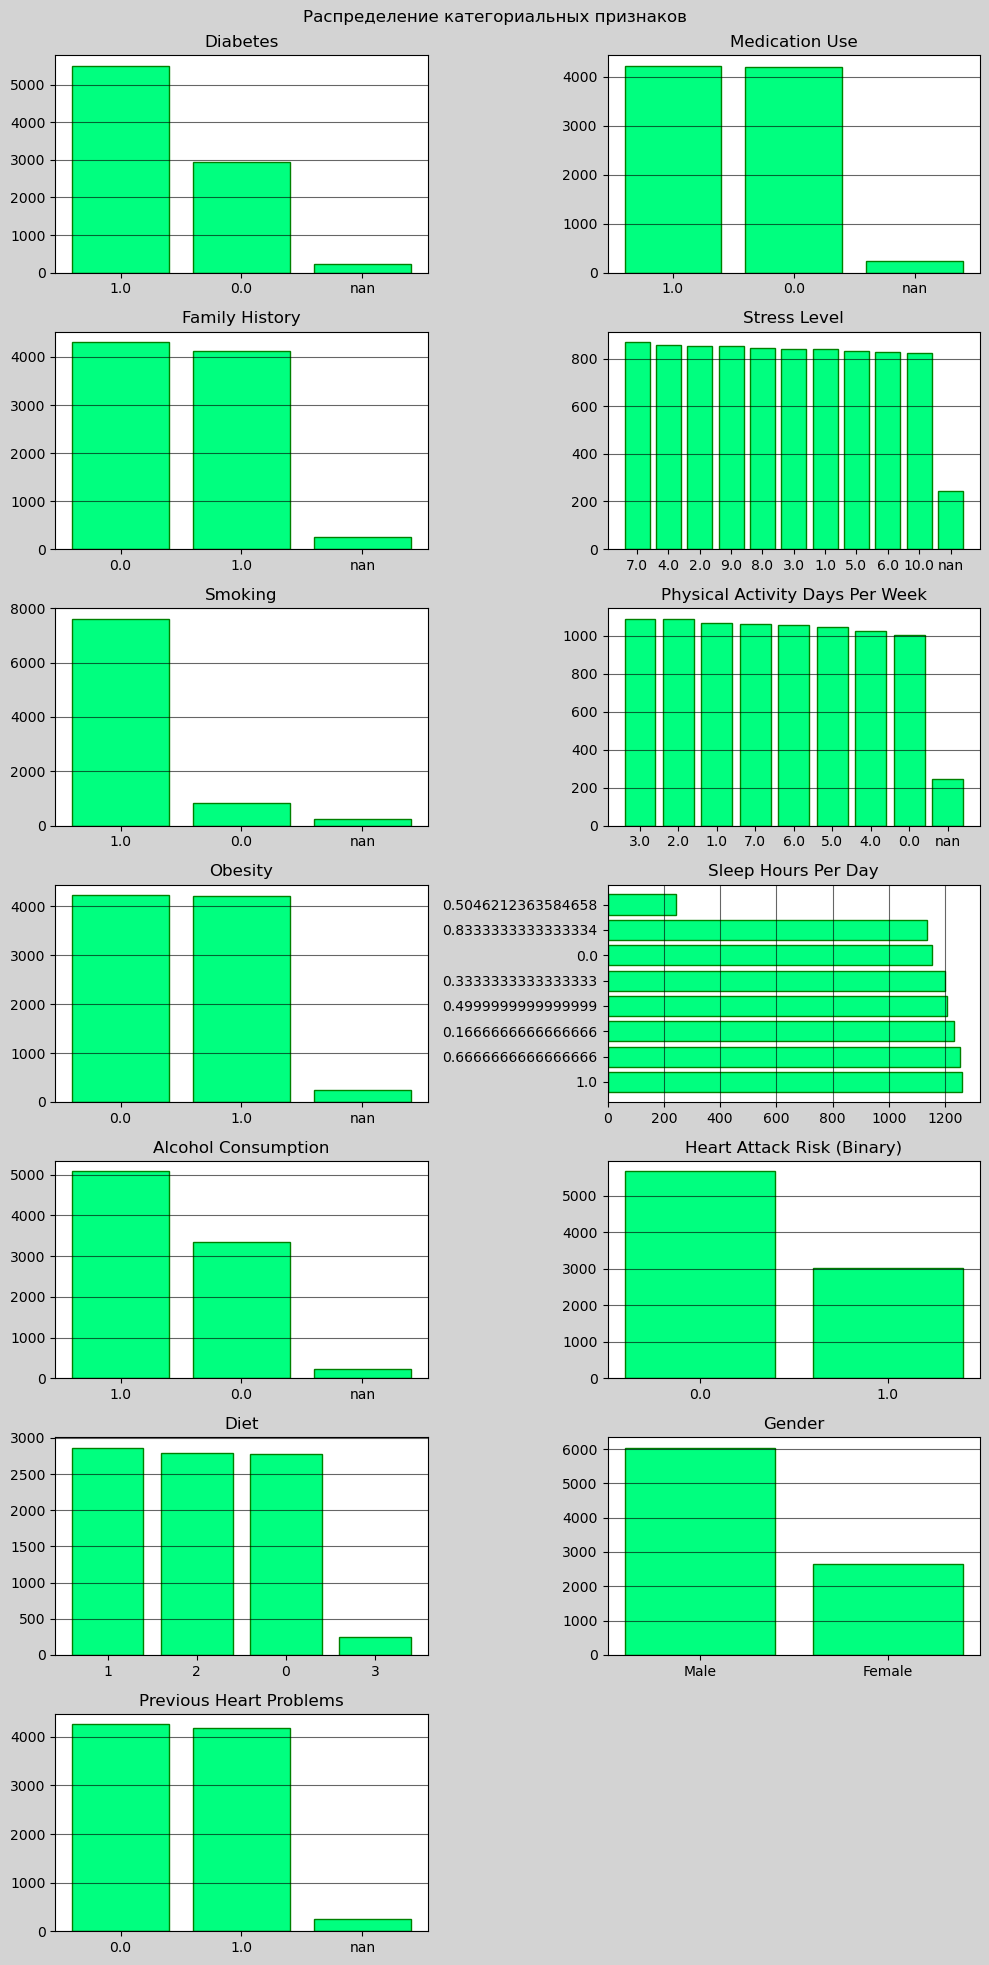

In [94]:
#Визуализация распределений категориальных признаков :
fig, axes = plt.subplots(7, 2, figsize=(10, 20), facecolor='lightgray')
color = 'springgreen'
edgecolor = 'green'
axes[0, 0].bar(data[category[0]].value_counts().index, data[category[0]].value_counts().values, color=color, edgecolor=edgecolor)
axes[1, 0].bar(data[category[1]].value_counts().index, data[category[1]].value_counts().values, color=color, edgecolor=edgecolor)
axes[2, 0].bar(data[category[2]].value_counts().index, data[category[2]].value_counts().values, color=color, edgecolor=edgecolor)
axes[3, 0].bar(data[category[3]].value_counts().index, data[category[3]].value_counts().values, color=color, edgecolor=edgecolor)
axes[4, 0].bar(data[category[4]].value_counts().index, data[category[4]].value_counts().values, color=color, edgecolor=edgecolor)
axes[5, 0].bar(data[category[5]].value_counts().index, data[category[5]].value_counts().values, color=color, edgecolor=edgecolor)
axes[6, 0].bar(data[category[6]].value_counts().index, data[category[6]].value_counts().values, color=color, edgecolor=edgecolor)
axes[0, 1].bar(data[category[7]].value_counts().index, data[category[7]].value_counts().values, color=color, edgecolor=edgecolor)
axes[1, 1].bar(data[category[8]].value_counts().index, data[category[8]].value_counts().values, color=color, edgecolor=edgecolor)
axes[2, 1].bar(data[category[9]].value_counts().index, data[category[9]].value_counts().values, color=color, edgecolor=edgecolor)
axes[3, 1].barh(data[category[10]].value_counts().index, data[category[10]].value_counts().values, color=color, edgecolor=edgecolor)
axes[4, 1].bar(data[category[11]].value_counts().index, data[category[11]].value_counts().values, color=color, edgecolor=edgecolor)
axes[5, 1].bar(data[category[12]].value_counts().index, data[category[12]].value_counts().values, color=color, edgecolor=edgecolor)
axes[6, 1].axis('off')
axes[0, 0].set_title(category[0])
axes[1, 0].set_title(category[1])
axes[2, 0].set_title(category[2])
axes[3, 0].set_title(category[3])
axes[4, 0].set_title(category[4])
axes[5, 0].set_title(category[5])
axes[6, 0].set_title(category[6])
axes[0, 1].set_title(category[7])
axes[1, 1].set_title(category[8])
axes[2, 1].set_title(category[9])
axes[3, 1].set_title(category[10])
axes[4, 1].set_title(category[11])
axes[5, 1].set_title(category[12])
axes[0, 0].grid(axis='y', color='black', alpha=0.6)
axes[1, 0].grid(axis='y', color='black', alpha=0.6)
axes[2, 0].grid(axis='y', color='black', alpha=0.6)
axes[3, 0].grid(axis='y', color='black', alpha=0.6)
axes[4, 0].grid(axis='y', color='black', alpha=0.6)
axes[5, 0].grid(axis='y', color='black', alpha=0.6)
axes[6, 0].grid(axis='y', color='black', alpha=0.6)
axes[0, 1].grid(axis='y', color='black', alpha=0.6)
axes[1, 1].grid(axis='y', color='black', alpha=0.6)
axes[2, 1].grid(axis='y', color='black', alpha=0.6)
axes[3, 1].grid(axis='x', color='black', alpha=0.6)
axes[4, 1].grid(axis='y', color='black', alpha=0.6)
axes[5, 1].grid(axis='y', color='black', alpha=0.6)
fig.suptitle('Распределение категориальных признаков')
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

**Выводы исследования датасета:**\
Данные успешно загружены, просмотрены.\
Установлено, что количественные признаки отмасштабированы с помощью алгоритма MinMaxScaler (диапазон значений от 0 до 1).\
Распределения признаков визуализированы.\
Наблюдается дисбаланс классов:\
В количественных признаках: 'Blood sugar', 'CK-MB', 'Troponin'.\
В категориальных признаках: 'Diabetes', 'Smoking', 'Heart Attack Risk (целевой признак)', 'Gender' (наблюдений за мужчинами в разы больше, чем за женщинами).

Задачи предобработки на основе исследования:
1. Проверить и удалить явные дубликаты.
2. Удалить пропуски.
3. Составить матрицу корреляций количественных признаков.
4. Отобрать признаки для обучения модели.

**------------------------------------------------------------**Предобработка данных**------------------------------------------------------------**

In [95]:
#Проверка явных дубликатов :
sum(data.duplicated())

0

In [96]:
#Проверка явных пропусков :
data.isna().sum()

Unnamed: 0                         0
Age                                0
Cholesterol                        0
Heart rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Heart Attack Risk (Binary)         0
Blood sugar                        0
CK-MB                              0
Troponin                           0
Gender                             0
Systolic blood pressure            0
Diastolic blood pressure           0
i

In [97]:
#Проверка строковых значений 'nan' :
data[data == 'nan'].count()

Unnamed: 0                           0
Age                                  0
Cholesterol                          0
Heart rate                           0
Diabetes                           243
Family History                     243
Smoking                            243
Obesity                            243
Alcohol Consumption                243
Exercise Hours Per Week              0
Diet                                 0
Previous Heart Problems            243
Medication Use                     243
Stress Level                       243
Sedentary Hours Per Day              0
Income                               0
BMI                                  0
Triglycerides                        0
Physical Activity Days Per Week    243
Sleep Hours Per Day                  0
Heart Attack Risk (Binary)           0
Blood sugar                          0
CK-MB                                0
Troponin                             0
Gender                               0
Systolic blood pressure  

In [98]:
#Удаление строковых значений 'nan' :
data = data[data != 'nan']

In [99]:
#Проверка удаления строковых значений 'nan' :
data[data == 'nan'].count()

Unnamed: 0                         0
Age                                0
Cholesterol                        0
Heart rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Heart Attack Risk (Binary)         0
Blood sugar                        0
CK-MB                              0
Troponin                           0
Gender                             0
Systolic blood pressure            0
Diastolic blood pressure           0
i

In [100]:
#Проврка пропусков после удаления строк nan :
data.isna().sum()

Unnamed: 0                           0
Age                                  0
Cholesterol                          0
Heart rate                           0
Diabetes                           243
Family History                     243
Smoking                            243
Obesity                            243
Alcohol Consumption                243
Exercise Hours Per Week              0
Diet                                 0
Previous Heart Problems            243
Medication Use                     243
Stress Level                       243
Sedentary Hours Per Day              0
Income                               0
BMI                                  0
Triglycerides                        0
Physical Activity Days Per Week    243
Sleep Hours Per Day                  0
Heart Attack Risk (Binary)           0
Blood sugar                          0
CK-MB                                0
Troponin                             0
Gender                               0
Systolic blood pressure  

In [101]:
#Удаление пропусов :
data = data.dropna()

In [102]:
#Проверка удаления пропусков :
data.isna().sum()

Unnamed: 0                         0
Age                                0
Cholesterol                        0
Heart rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Heart Attack Risk (Binary)         0
Blood sugar                        0
CK-MB                              0
Troponin                           0
Gender                             0
Systolic blood pressure            0
Diastolic blood pressure           0
i

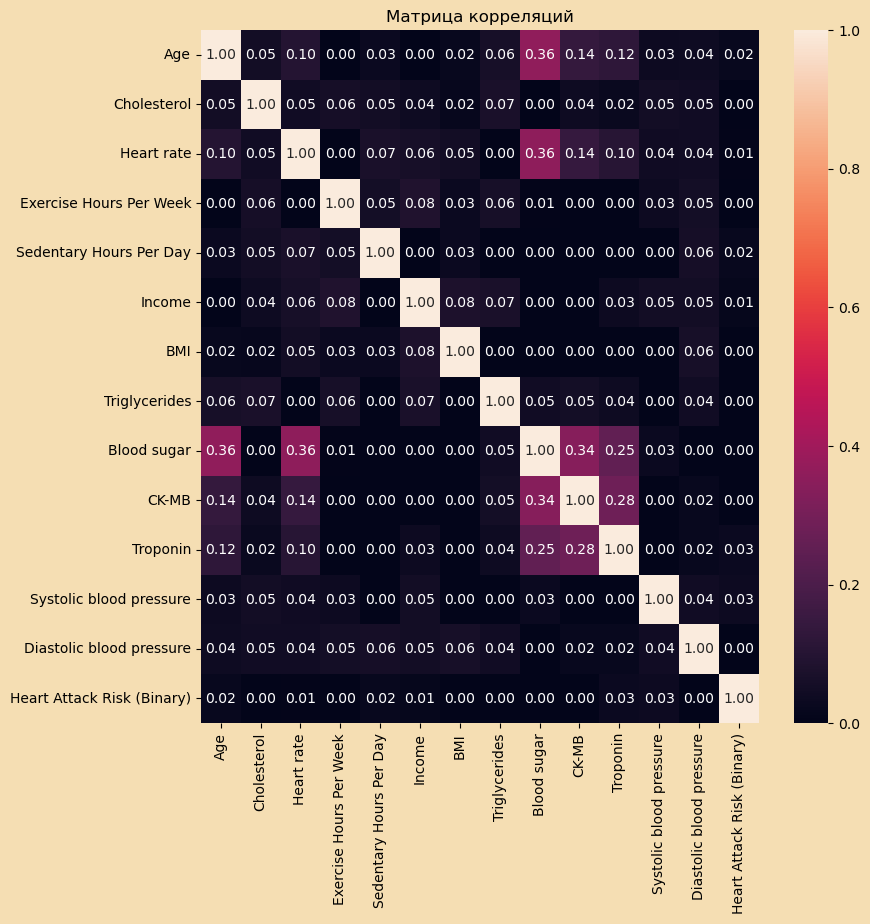

In [103]:
#Построение матрицы корреляций количественных признаков:

#Приведение таргета к числовому типу
data['Heart Attack Risk (Binary)'] = data['Heart Attack Risk (Binary)'].astype('float').astype('int')
#Выбор количественных признаков и таргета
quantitative_target = quantitative + ['Heart Attack Risk (Binary)']
#Построение графика
plt.figure(figsize=(9, 9), facecolor='wheat')
sns.heatmap(data[quantitative_target].phik_matrix(interval_cols=quantitative_target),
    annot=True, fmt='.2f'
    )
plt.title('Матрица корреляций')
plt.savefig('phik_matrix.png')
plt.show()

In [104]:
#Группируем признаки по типу необходимого преобразования для отбора категориальных признаков
ohe_cols_select = [
    'Diabetes',
    'Family History',
    'Smoking',
    'Obesity',
    'Alcohol Consumption',
    'Diet',
    'Previous Heart Problems',
    'Medication Use', 
    'Gender']
ord_cols_select = [
    'Stress Level',
    'Physical Activity Days Per Week',
    'Sleep Hours Per Day'
    ]
#Выделение датасета с категориальными признаками
data_select = data[category]

In [105]:
data_select.head()

,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Diet,Previous Heart Problems,Medication Use,Stress Level,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Gender
0,1.0,1.0,1.0,1.0,1.0,1,1.0,0.0,8.0,3.0,0.3333333333333333,0,Male
1,1.0,1.0,0.0,0.0,1.0,2,1.0,0.0,9.0,3.0,0.8333333333333334,0,Female
2,1.0,0.0,1.0,1.0,1.0,2,1.0,1.0,6.0,2.0,1.0,0,Female
3,0.0,0.0,1.0,0.0,1.0,0,0.0,1.0,3.0,0.0,0.3333333333333333,1,Female
4,0.0,0.0,1.0,0.0,1.0,1,0.0,0.0,8.0,5.0,1.0,1,Male


In [106]:
X_select = data_select.drop(['Heart Attack Risk (Binary)'], axis=1)
y_select = data_select['Heart Attack Risk (Binary)']

In [107]:
X_select.shape

(8442, 12)

In [108]:
y_select.shape

(8442,)

In [109]:
#Создание пайплайна ohe-кодирования :
ohe_pipe_select = Pipeline([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])
#Создание пайплайна ordinal-кодирования :
ord_pipe_select = Pipeline([
    ('ord', OrdinalEncoder(categories=[
        ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0', '10.0'],
        ['0.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0'],
        ['0.0', '0.1666666666666666', '0.3333333333333333', '0.4999999999999999', '0.6666666666666666', '0.8333333333333334', '1.0']
    ]))
    ])
#Пайплайн преобразования данных для отбора признаков :
preprocessor_select = ColumnTransformer([
    ('ohe', ohe_pipe_select, ohe_cols_select),
    ('ord', ord_pipe_select, ord_cols_select)
    ]
    )

In [110]:
#Кодирование категориальных признаков
X_encoded_select = preprocessor_select.fit_transform(X_select)

In [111]:
#Получаем важность признаков:
mi_scores = mutual_info_classif(X_encoded_select, y_select, discrete_features=True)
mi_results = pd.Series(mi_scores, index=preprocessor_select.get_feature_names_out())
print(mi_results.sort_values(ascending=False))

ord__Physical Activity Days Per Week    5.012027e-04
ord__Stress Level                       4.584324e-04
ord__Sleep Hours Per Day                3.436277e-04
ohe__Diet_1                             1.780732e-04
ohe__Diabetes_1.0                       1.317142e-04
ohe__Obesity_1.0                        1.137735e-04
ohe__Alcohol Consumption_1.0            1.056653e-04
ohe__Gender_Male                        2.710524e-05
ohe__Diet_2                             2.301855e-05
ohe__Smoking_1.0                        1.395788e-05
ohe__Family History_1.0                 4.269042e-06
ohe__Previous Heart Problems_1.0        1.429645e-06
ohe__Medication Use_1.0                 1.059638e-07
dtype: float64


In [112]:
#Отбор признаков на основе матрицы корреляций и оценки важности категориальных признаков:
features = [
'Age',
'Heart rate',
'Sedentary Hours Per Day',
'Income',
'Troponin',
'Systolic blood pressure',
'Physical Activity Days Per Week',
'Stress Level',
'Sleep Hours Per Day',
'Heart Attack Risk (Binary)'
]
data = data[features]

In [113]:
#Просмотр признаков тренировочного датасета :
data.columns

Index(['Age', 'Heart rate', 'Sedentary Hours Per Day', 'Income', 'Troponin',
       'Systolic blood pressure', 'Physical Activity Days Per Week',
       'Stress Level', 'Sleep Hours Per Day', 'Heart Attack Risk (Binary)'],
      dtype='object')

In [114]:
#Просмотр размерности тренировочного датасета :
data.shape

(8442, 10)

**Вывод предобработки и отбора принаков:**\
Данные предобработаны, нулевые и пропущенные значения удалены, отобрано 9 признаков для обучения моделей.

**------------------------------------------------------------**Обучение модели**------------------------------------------------------------**

In [115]:
#Разделение выборки на тренировочную и тестовую, используем стратификацию при разделении :
X = data.drop(['Heart Attack Risk (Binary)'], axis=1)
y = data['Heart Attack Risk (Binary)']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE
    )

In [116]:
X.shape

(8442, 9)

In [117]:
y.shape

(8442,)

In [118]:
#Группируем признаки по типу необходимого преобразования :
ord_cols = [
    'Stress Level',
    'Physical Activity Days Per Week',
    'Sleep Hours Per Day'
    ]

In [119]:
print(sorted(data['Stress Level'].unique()))
print(sorted(data['Physical Activity Days Per Week'].unique()))
print(sorted(data['Sleep Hours Per Day'].unique()))

['1.0', '10.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0']
['0.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0']
['0.0', '0.1666666666666666', '0.3333333333333333', '0.4999999999999999', '0.6666666666666666', '0.8333333333333334', '1.0']


In [120]:
#Создание пайплайна ordinal-кодирования :
ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=[
        ['1.0', '10.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0'],
        ['0.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0'],
        ['0.0', '0.1666666666666666', '0.3333333333333333', '0.4999999999999999', '0.6666666666666666', '0.8333333333333334', '1.0']
    ], 
    handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ])
#Пайплайн преобразования данных :
data_preprocessor = ColumnTransformer([
    ('ord', ord_pipe, ord_cols)
    ],
    remainder='passthrough'
    )

In [121]:
#Общий пайплайн DLogisticRegression :
pipe_LogisticRegression = Pipeline(
    [
    ('preprocessor', data_preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
    ])
#Гиперпараметры LogisticRegression :
param_LogisticRegression = [
    {
    'model__C': range(1, 10),
    'model__solver': ['lbfgs', 'saga']
    }
    ]

In [122]:
#Выбираем полный перебор параметров LogisticRegression с помощью GridSearchCV.
#в качестве метрики выберем recall (нахождение true positive классов - "высокий риск сердечного приступа") 
#в соответствии с целями задачи.
gscv_LogisticRegression = GridSearchCV(
    pipe_LogisticRegression, 
    param_grid=param_LogisticRegression,
    cv=5,
    scoring='recall',
    n_jobs=-1
    )

In [123]:
#Общий пайплайн DecisionTreeClassifier :
pipe_DecisionTreeClassifier = Pipeline(
    [
    ('preprocessor', data_preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])
#Гиперпараметры DecisionTreeClassifier :
param_DecisionTreeClassifier = [
    {
    'model__max_depth': range(1, 30),
    'model__min_samples_split': range(2, 30),
    'model__min_samples_leaf': range(1, 30)
    }
    ]

In [124]:
#Выбираем полный перебор параметров DecisionTreeClassifier с помощью GridSearchCV.
#в качестве метрики выберем recall (нахождение true positive классов - "высокий риск сердечного приступа") 
#в соответствии с целями задачи.
gscv_DecisionTreeClassifier = GridSearchCV(
    pipe_DecisionTreeClassifier, 
    param_grid=param_DecisionTreeClassifier,
    cv=5,
    scoring='recall',
    n_jobs=-1
    )

In [125]:
#Общий пайплайн KNeighborsClassifier :
pipe_KNeighborsClassifier = Pipeline(
    [
    ('preprocessor', data_preprocessor),
    ('model', KNeighborsClassifier())
    ])
#Гиперпараметры KNeighborsClassifier :
param_KNeighborsClassifier = [
    {
    'model__n_neighbors': range(5, 31),
    'model__metric' : ['minkowski', 'manhattan']
    }
    ]

In [126]:
#Выбираем полный перебор параметров KNeighborsClassifier с помощью GridSearchCV.
#в качестве метрики выберем recall (нахождение true positive классов - "высокий риск сердечного приступа") 
#в соответствии с целями задачи.
gscv_KNeighborsClassifier = GridSearchCV(
    pipe_KNeighborsClassifier, 
    param_grid=param_KNeighborsClassifier,
    cv=5,
    scoring='recall',
    n_jobs=-1
    )

In [127]:
#Обучаем класс на тренировочной выборке и подбираем лучшую модель :
gscv_LogisticRegression.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': range(1, 10), 'model__solver': ['lbfgs', 'saga']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [128]:
#Обучаем класс на тренировочной выборке и подбираем лучшую модель :
gscv_DecisionTreeClassifier.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__max_depth': range(1, 30), 'model__min_samples_leaf': range(1, 30), 'model__min_samples_split': range(2, 30)}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [129]:
#Обучаем класс на тренировочной выборке и подбираем лучшую модель :
gscv_KNeighborsClassifier.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__metric': ['minkowski', 'manhattan'], 'model__n_neighbors': range(5, 31)}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the s

In [130]:
#Просмотр метрики recall лучшей модели после кросс-валидации :
print('Метрика recall лучшей модели LogisticRegression на кросс-валидации:', gscv_LogisticRegression.best_score_)

Метрика recall лучшей модели LogisticRegression на кросс-валидации: 0.0008938558644934483


In [131]:
#Просмотр метрики recall лучшей модели после кросс-валидации :
print('Метрика recall лучшей модели DecisionTreeClassifier на кросс-валидации:', gscv_DecisionTreeClassifier.best_score_)

Метрика recall лучшей модели DecisionTreeClassifier на кросс-валидации: 0.3923108421220838


In [132]:
#Просмотр метрики recall лучшей модели после кросс-валидации :
print('Метрика recall лучшей модели KNeighborsClassifier на кросс-валидации:', gscv_KNeighborsClassifier.best_score_)

Метрика recall лучшей модели KNeighborsClassifier на кросс-валидации: 0.269446108980505


In [134]:
#Подбор порога для улучшения метрики recall DecisionTreeClassifier:
model1 = gscv_DecisionTreeClassifier.best_estimator_
probabilities1 = model.predict_proba(X_test)[:, 1]
custom_threshold1 = 0.3
y_pred_custom1 = (probabilities1 >= custom_threshold1).astype(int)
recall1 = recall_score(y_test, y_pred_custom1)
print(f'Recall при пороге {custom_threshold1}: {recall1}')

Recall при пороге 0.3: 0.5419354838709678


In [135]:
#Подбор порога для улучшения метрики recall KNeighborsClassifier:
model2 = gscv_KNeighborsClassifier.best_estimator_
probabilities2 = model2.predict_proba(X_test)[:, 1]
custom_threshold2 = 0.2
y_pred_custom2 = (probabilities2 >= custom_threshold2).astype(int)
recall2 = recall_score(y_test, y_pred_custom2)
print(f'Recall при пороге {custom_threshold2}: {recall2}')

Recall при пороге 0.2: 0.863225806451613


In [136]:
#Сохранение лучшей модели KNeighborsClassifier
import joblib
model = model2
joblib.dump(model, 'model.joblib')

['model.joblib']

In [137]:
#Загрузка данных тестирования модели:
testing = pd.read_csv('heart_test.csv')

In [140]:
#Просмотр данных для тестирования:
testing.head()

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,...,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093,7746
1,1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,...,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860,4202
2,2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,...,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070,6632
3,3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,...,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814,4639
4,4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,...,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349,4825


In [141]:
#Получение предсказаний в форме согласно условиям задачи:
predictions = model.predict_proba(testing)[:, 1]
predictions = (predictions >= 0.2).astype(int)
testing['prediction'] = predictions

In [142]:
#Просмотр результатов предсказаний:
testing['prediction'].value_counts()

prediction
1    959
0      7
Name: count, dtype: int64

In [143]:
#Просмотр результатов предсказаний:
testing[['id', 'prediction']].head()

,id,prediction
0,7746,1
1,4202,1
2,6632,1
3,4639,1
4,4825,1


**------------------------------------------------------------**ВЫВОДЫ**------------------------------------------------------------**

1) Проведен исследовательский анализ данных, изучено распределение количественных и категориальных признаков.
2) Выполнена предобработка данных.
3) На основании матрицы корреляций и оценки важности категориальных признаков отобраны признаки для обучения модели.
4) Наилучшая модель DecisionTreeClassifier показала самую высокую метрику recall, но из-за особенностей алгоритма модель имеет предел понижения порога отнесения объекта к классу "1". Поэтому для предсказаний выбрана модель KNeighborsClassifier, которая при пороге 0.2 показала метрику recall = 0.86.
5) Модель сохранена в файл для загрузки в API, на данных для тестирования проверено, корректно ли трансформер модели преобразует признаки и выполняет предсказания.